
### Goal: Predict whether a loan will be approved (Y) or not approved (N) based on applicant details.


    Shape: 614 rows × 13 columns

    Target Variable: Loan_Status

        Y → Loan Approved
        
        N → Loan Rejected

✔ Important Predictors (domain insight)

    Credit_History
    
    ApplicantIncome
    
    LoanAmount
    
    Property_Area

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

%matplotlib inline


In [ ]:
df = pd.read_csv("Loan Prediction.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'Loan Prediction.csv'

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [9]:

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isna().sum())


Dataset Shape: (614, 13)

Missing Values:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [5]:
print("Dataset Shape:", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
Dataset Shape: None


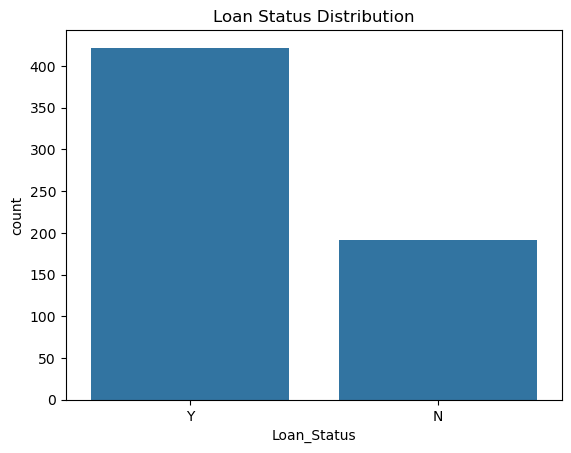

In [6]:
sns.countplot(x="Loan_Status", data=df)

plt.title("Loan Status Distribution")
plt.show()


In [7]:
df['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [8]:
df.fillna({
    "Gender": df["Gender"].mode()[0],
    "Married": df["Married"].mode()[0],
    "Dependents": df["Dependents"].mode()[0],
    "Self_Employed": df["Self_Employed"].mode()[0],
    "LoanAmount": df["LoanAmount"].median(),
    "Loan_Amount_Term": df["Loan_Amount_Term"].mode()[0],
    "Credit_History": df["Credit_History"].mode()[0],
}, inplace=True)


In [10]:
skewed_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]

for col in skewed_cols:
    df[col] = np.log1p(df[col])


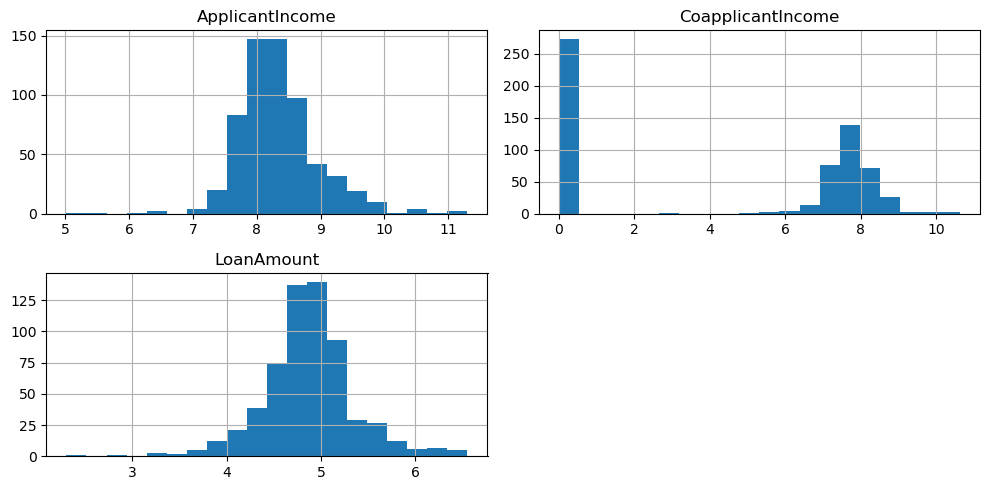

In [11]:
df[skewed_cols].hist(bins=20, figsize=(10,5))
plt.tight_layout()
plt.show()


In [12]:
le = LabelEncoder()

cat_features = [
    "Gender", "Married", "Dependents",
    "Education", "Self_Employed",
    "Property_Area", "Loan_Status"
]

for col in cat_features:
    df[col] = le.fit_transform(df[col])


In [13]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,8.674197,0.000000,4.859812,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,8.430327,7.319202,4.859812,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,8.006701,0.000000,4.204693,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,7.857094,7.765993,4.795791,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,8.699681,0.000000,4.955827,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,0,0,7.972811,0.000000,4.276666,360.0,1.0,0,1
610,LP002979,1,1,3,0,0,8.320448,0.000000,3.713572,180.0,1.0,0,1
611,LP002983,1,1,1,0,0,8.996280,5.484797,5.537334,360.0,1.0,2,1
612,LP002984,1,1,2,0,0,8.933796,0.000000,5.236442,360.0,1.0,2,1


In [14]:
X = df.drop(["Loan_ID", "Loan_Status"], axis=1)
y = df["Loan_Status"]


In [15]:
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0,0,8.674197,0.000000,4.859812,360.0,1.0,2
1,1,1,1,0,0,8.430327,7.319202,4.859812,360.0,1.0,0
2,1,1,0,0,1,8.006701,0.000000,4.204693,360.0,1.0,2
3,1,1,0,1,0,7.857094,7.765993,4.795791,360.0,1.0,2
4,1,0,0,0,0,8.699681,0.000000,4.955827,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,7.972811,0.000000,4.276666,360.0,1.0,0
610,1,1,3,0,0,8.320448,0.000000,3.713572,180.0,1.0,0
611,1,1,1,0,0,8.996280,5.484797,5.537334,360.0,1.0,2
612,1,1,2,0,0,8.933796,0.000000,5.236442,360.0,1.0,2


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [17]:
scaler = StandardScaler()

X_train[skewed_cols] = scaler.fit_transform(X_train[skewed_cols])
X_test[skewed_cols] = scaler.transform(X_test[skewed_cols])


In [18]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [19]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]


In [20]:
y_pred

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0])

In [21]:
y_pred_prob 

array([0.08645157, 0.84939501, 0.73132376, 0.82165915, 0.86024799,
       0.70435385, 0.78618836, 0.80548482, 0.69487856, 0.66292797,
       0.81998076, 0.83704143, 0.77748937, 0.82886055, 0.18066693,
       0.1200301 , 0.76133107, 0.13755496, 0.13665601, 0.78818106,
       0.15361237, 0.71701728, 0.78808827, 0.80433708, 0.81493269,
       0.75662049, 0.73531256, 0.86097207, 0.08829122, 0.82292783,
       0.79730584, 0.84392989, 0.85108275, 0.83110097, 0.62351428,
       0.7875719 , 0.08157474, 0.86314184, 0.7132154 , 0.81945275,
       0.85280186, 0.7452895 , 0.71416537, 0.85148996, 0.77743142,
       0.83946383, 0.77213785, 0.7743435 , 0.82389452, 0.63557336,
       0.19424141, 0.85366318, 0.11269935, 0.80598925, 0.67531671,
       0.70548793, 0.10438494, 0.86931111, 0.83413548, 0.69121245,
       0.09926885, 0.64526861, 0.79629955, 0.7295425 , 0.79054635,
       0.7347665 , 0.80065163, 0.8757803 , 0.66018046, 0.79643832,
       0.85257641, 0.12719095, 0.82542171, 0.7394253 , 0.83128

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8536585365853658


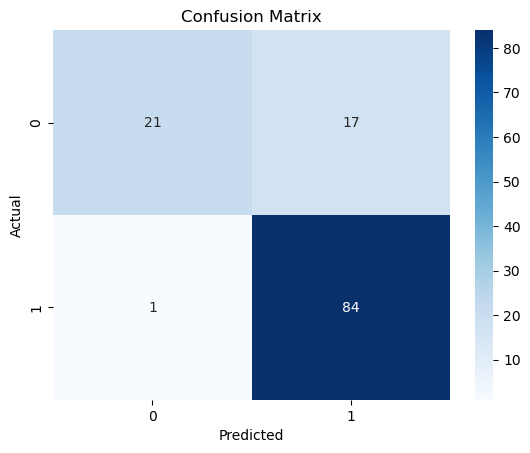

In [23]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [24]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.8291021671826626


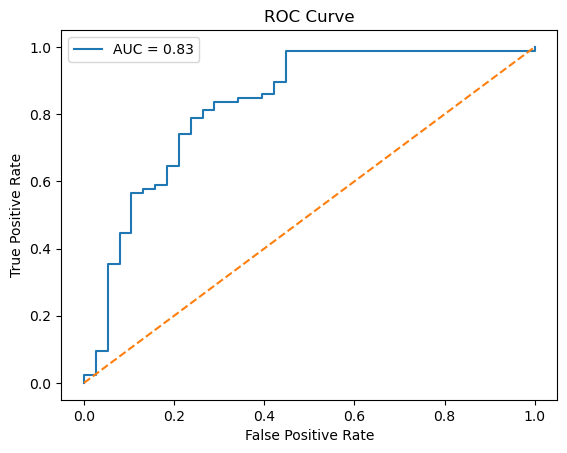

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

feature_importance


,Feature,Coefficient
9,Credit_History,3.131966
1,Married,0.396361
6,CoapplicantIncome,0.196733
2,Dependents,0.106160
5,ApplicantIncome,0.102587
10,Property_Area,0.070650
8,Loan_Amount_Term,0.000476
7,LoanAmount,-0.123212
4,Self_Employed,-0.139362
0,Gender,-0.268303
